# AA200 – Problem Set 5, Problem 1
## Load Distribution of a Wing with Finite Span
All quantities are non-dimensionalized by the span $b$ and reference circulation $\Gamma_0$ 


## 1. Circulation Distribution

Given the figure we have: 


$$\Gamma(y) = \begin{cases} \dfrac{\Gamma_0}{b/4}\left(y + \dfrac{b}{2}\right) & y\in\left[-\dfrac{b}{2},-\dfrac{b}{4}\right] \\[6pt]\Gamma_0 & y\in\left[-\dfrac{b}{4},\dfrac{b}{4}\right] \\[6pt]\dfrac{-\Gamma_0}{b/4}\left(y - \dfrac{b}{2}\right) & y\in\left[\dfrac{b}{4},\dfrac{b}{2}\right]\end{cases}$$

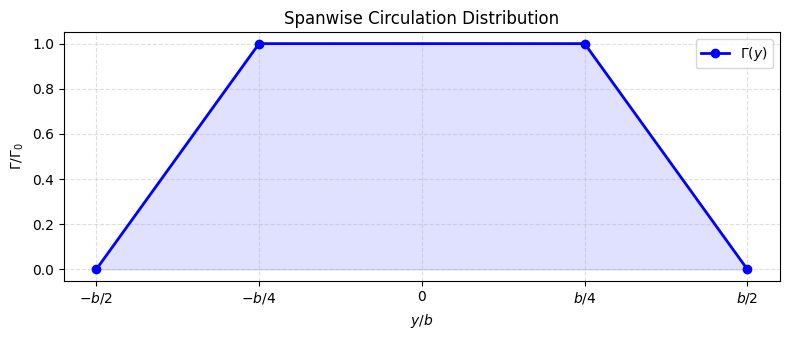

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

b = 1.0  # normalized
y = np.array([-b/2, -b/4, b/4, b/2])
G = np.array([0, 1, 1, 0])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(y, G, 'b-o', lw=2, ms=6, label=r'$\Gamma(y)$')
ax.fill_between(y, G, alpha=0.12, color='blue')
ax.set_xlabel(r'$y/b$'); ax.set_ylabel(r'$\Gamma/\Gamma_0$')
ax.set_title('Spanwise Circulation Distribution')
ax.set_xticks([-b/2,-b/4,0,b/4,b/2])
ax.set_xticklabels([r'$-b/2$',r'$-b/4$',r'$0$',r'$b/4$',r'$b/2$'])
ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.tight_layout(); plt.show()


## 2. Trailing Vortex System

By Helmholtz's theorem, the trailing vortex sheet strength is:

$$\gamma(y) = \frac{d\Gamma}{dy}$$

| Region | $d\Gamma/dy$ | $\gamma$ |
|---|---|---|
| $y \in (-b/2,\,-b/4)$ | $+4\Gamma_0/b$ | $+4\Gamma_0/b$ |
| $y \in (-b/4,\,+b/4)$ | $0$ | $0$ |
| $y \in (+b/4,\,+b/2)$ | $-4\Gamma_0/b$ | $-4\Gamma_0/b$ |

The vortex sheet strength is directly proportional to the spanwise gradient of the circulation.  
Since the circulation increases on the left panel and decreases on the right panel, two vortex sheets of opposite sign are shed from the discontinuities at $y=\pm b/4$.  
No vortex sheet is generated in the central region because the circulation is constant there.

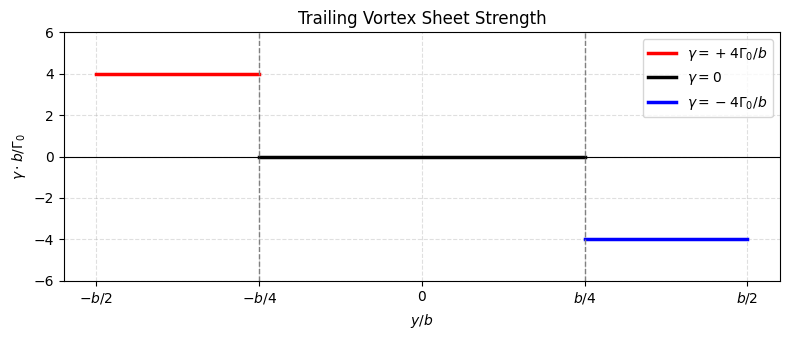

In [ ]:
b = 1.0

# Vortex sheet strength: gamma = dGamma/dy
y_left  = np.array([-b/2, -b/4])
y_mid   = np.array([-b/4,  b/4])
y_right = np.array([ b/4,  b/2])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(y_left,  [ 4, 4], 'r-',  lw=2.5, label=r'$\gamma = +4\Gamma_0/b$')
ax.plot(y_mid,   [ 0, 0], 'k-',  lw=2.5, label=r'$\gamma = 0$')
ax.plot(y_right, [-4,-4], 'b-',  lw=2.5, label=r'$\gamma = -4\Gamma_0/b$')

# Discontinuities at kinks
ax.axvline(-b/4, color='gray', ls='--', lw=1)
ax.axvline( b/4, color='gray', ls='--', lw=1)

ax.set_xlabel(r'$y/b$')
ax.set_ylabel(r'$\gamma \cdot b/\Gamma_0$')
ax.set_title('Trailing Vortex Sheet Strength')
ax.set_xticks([-b/2, -b/4, 0, b/4, b/2])
ax.set_xticklabels([r'$-b/2$', r'$-b/4$', r'$0$', r'$b/4$', r'$b/2$'])
ax.set_ylim(-6, 6)
ax.axhline(0, color='k', lw=0.8)
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 3. Downwash / Upwash on the Wing Plane

### 3.1 Derivation

From the course notes, the induced velocity $w(y)$ (counting w>0 as an actual downwash) at spanwise position $y$ due to the trailing vortex sheet follows from the Biot–Savart law:

$$
w(y) = -\frac{1}{4\pi}\int_{-b/2}^{b/2}\frac{\gamma(t)}{y-t}\,dt
$$

However, in the plots below we consider the **physical vertical velocity component** with the coordinate system defined such that **$z$ is positive upward**.  
With this convention, **downwash corresponds to $w<0$**.

For the piecewise circulation distribution used in this model,

$$
w(y) = -\frac{\Gamma_0}{b\pi}\left[\int_{-b/2}^{-b/4}\frac{dt}{y-t} - \int_{b/4}^{b/2}\frac{dt}{y-t}\right]
$$

Evaluating the logarithmic integrals gives

$$
w(y) = -\frac{\Gamma_0}{b\pi}\left[\ln\left|y+\frac{b}{4}\right|-\ln\left|y+\frac{b}{2}\right|-\ln\left|y-\frac{b}{4}\right|+\ln\left|y-\frac{b}{2}\right|\right]
$$

which can be written compactly as

$$
w(y) = -\frac{\Gamma_0}{b\pi}\ln\left| \frac{y^2 - (b/4)^2}{y^2-(b/2)^2} \right|
$$

Because we define the **physical vertical velocity positive upward**, the quantity actually plotted is

$$
\boxed{w(y) = \frac{\Gamma_0}{b\pi}\ln\left| \frac{y^2 - (b/4)^2}{y^2-(b/2)^2} \right|}
$$

---

### 3.2 Sign and Physical Interpretation

Let

$$
R(y)=\left|\frac{y^2-(b/4)^2}{y^2-(b/2)^2}\right|
$$

If $R<1$, then $\ln R<0$ and therefore **$w<0$ (downwash)**.  
If $R>1$, then $\ln R>0$ and therefore **$w>0$ (upwash)**.

| Region | Sign of $w$ | Interpretation |
|---|---|---|
| $\|y\| < b/4$ | $w<0$ | **Downwash** |
| $b/4 < \|y\| < \sqrt{5/32}\,b$ | $w<0$ | **Downwash** |
| $\sqrt{5/32}\,b < \|y\| < b/2$ | $w>0$ | **Upwash** |
| $\|y\| > b/2$ | $w>0$ | **Upwash** |

Thus the inner lifting region induces **downwash**, while the influence of the tip vortices produces **upwash** near and outside the wing tips.

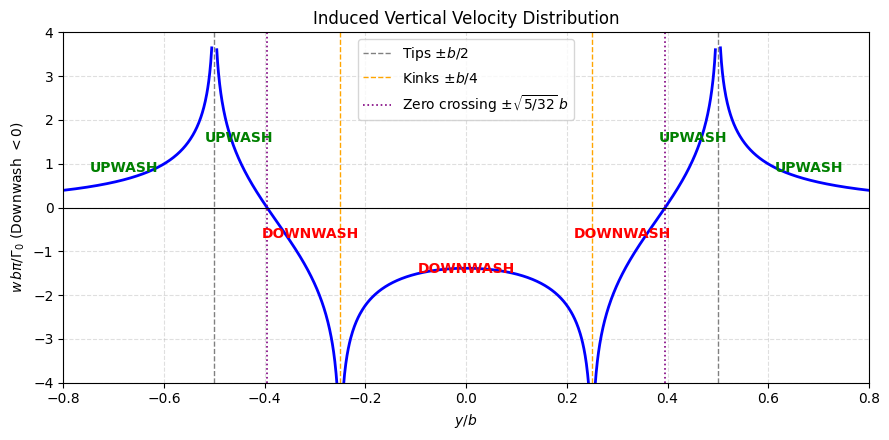

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def w_nondim(y, b=1.0):
    # Physical vertical velocity component, with z positive upward
    # => downwash corresponds to w < 0
    num = y**2 - (b/4)**2
    den = y**2 - (b/2)**2
    return np.log(np.abs(num / den))

b = 1.0
delta = 0.005
y0 = np.sqrt(5/32) * b   # zero crossing in b/4 < |y| < b/2

segments = [
    np.linspace(-0.8, -0.5 - delta, 300),
    np.linspace(-0.5 + delta, -0.25 - delta, 300),
    np.linspace(-0.25 + delta, 0.25 - delta, 400),
    np.linspace(0.25 + delta, 0.5 - delta, 300),
    np.linspace(0.5 + delta, 0.8, 300),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
for seg in segments:
    ax.plot(seg, w_nondim(seg, b=b), 'b-', lw=2)

ax.axhline(0, color='k', lw=0.8)
ax.axvline(-0.5, color='gray', ls='--', lw=1, label=r'Tips $\pm b/2$')
ax.axvline( 0.5, color='gray', ls='--', lw=1)
ax.axvline(-0.25, color='orange', ls='--', lw=1, label=r'Kinks $\pm b/4$')
ax.axvline( 0.25, color='orange', ls='--', lw=1)

# Zero crossings inside b/4 < |y| < b/2
ax.axvline(-y0, color='purple', ls=':', lw=1.2, label=r'Zero crossing $\pm\sqrt{5/32}\,b$')
ax.axvline( y0, color='purple', ls=':', lw=1.2)

ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-4, 4)
ax.set_xlabel(r'$y/b$')
ax.set_ylabel(r'$w\, b\pi/\Gamma_0$ (Downwash $<0$)')
ax.set_title('Induced Vertical Velocity Distribution')
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.4)

# Correct sign labels for z positive upward
ax.text(0, -1.5, 'DOWNWASH', ha='center', color='red', fontweight='bold')
ax.text(-0.31, -0.7, 'DOWNWASH', ha='center', color='red', fontweight='bold', fontsize=10)
ax.text( 0.31, -0.7, 'DOWNWASH', ha='center', color='red', fontweight='bold', fontsize=10)

ax.text(-0.45, 1.5, 'UPWASH', ha='center', color='green', fontweight='bold')
ax.text( 0.45, 1.5, 'UPWASH', ha='center', color='green', fontweight='bold')
ax.text(-0.68, 0.8, 'UPWASH', ha='center', color='green', fontweight='bold')
ax.text( 0.68, 0.8, 'UPWASH', ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()